In [17]:
import numpy as np
import torch
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

colors = ['b','g','darkred','c','mediumpurple','sienna']

%matplotlib inline

In [18]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)

# datasets
datasets = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","SIGLO","TRINITI"]
Nsets = len(datasets)

In [19]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.6000e+01 4.1900e-22 1.2151e-22]
 [2.0000e+01 3.1900e-22 9.2510e-23]
 [3.0000e+01 1.6600e-22 4.8140e-23]
 [5.0000e+01 3.6100e-23 1.1913e-23]
 [1.0000e+02 5.6000e-24 2.6320e-24]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.6000e+01 3.9700e-22 1.1513e-22]
 [2.0000e+01 3.7000e-22 1.0730e-22]
 [3.0000e+01 4.5600e-22 1.3224e-22]
 [5.0000e+01 5.7800e-22 1.6762e-22]
 [1.0000e+02 3.2800e-22 9.5120e-23]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.6000e+01 6.0900e-23 2.0097e-23]
 [2.0000e+01 6.4400e-23 2.1252e-23]
 [3.0000e+01 4.5400e-23 2.1338e-23]
 [5.0000e+01 1.1200e-23 5.2640e-24]
 [1.0000e+02 5.4100e-24 2.5427e-24]]
Excitation, le

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Tsurubuchi, S., Miyazaki, T., & Motohashi, K. (1996). Electron-impact emission cross sections of Ar. Journal of Physics B: Atomic, Molecular and Optical Physics, 29(9), 1785–1801. https://doi.org/10.1088/0953-4075/29/9/022
15.071227991895011
Li, G. P., Takayanagi, T., Wakiya, K., Suzuki, H., Ajiro, T., Yagi, S., Kano, S. S., & Takuma, H. (1988). Determination o

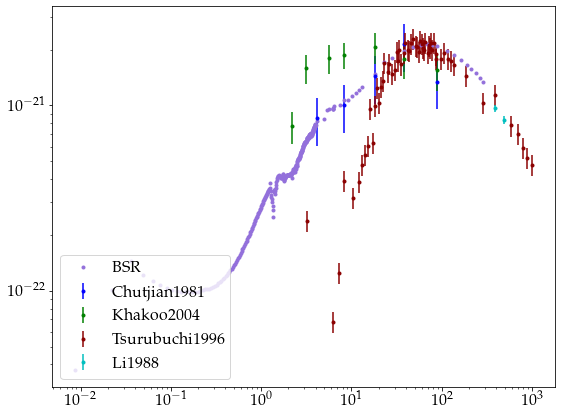

In [20]:
from models import *
level = 4
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0

targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
        targetrefs += ['BSR']
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.5
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([2.54e0,1])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
# model0 = Excite_resonance(4,theta_ref,Etest)
# mask = model0 > 1.0e-23
# Etest = Etest[mask]
# model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
    if(k==4):
        plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
    else:
        plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
# plt.plot(Etest[mask]-E_ext[3],model0[mask],'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./excitation.6.png',dpi=300)


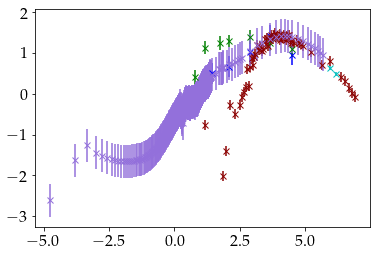

In [21]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - E_ext[level-1])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [torch.Tensor(temp)]

# Wlog = Wlog[:2] + Wlog[3:]
    
Wlogm, Nw = 0.0, 0
for wlogk in Wlog:
    Nw += wlogk.size(0)
    Wlogm += wlogk[:,1].sum()
Wlogm /= Nw

for k, wlogk in enumerate(Wlog):
    wlogk[:,1] -= Wlogm
        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])

In [23]:
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0].repeat(wlogk.size(0),1)
    xd += [temp - temp.t()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]

class ExpKernel(torch.nn.Module):
    def __init__(self):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        self.var = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.scale = torch.nn.Parameter(1.0 + 0.1 * torch.randn(()))
        self.var.clamp(min=0.0)
        self.scale.clamp(min=0.0)

    def forward(self, xd):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        return self.var * torch.exp( - xd ** 2 / self.scale )
    
    def covariance(self, x1, x2):
        assert((x1.dim()==1) and (x2.dim()==1))
        xd = x1.repeat(x2.size(0),1).t() - x2.repeat(x1.size(0),1)
        return self.var * torch.exp( - xd ** 2 / self.scale )
    
class ExpKernelPack(torch.nn.Module):
    def __init__(self,n=1):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        self.n = n
        self.var = torch.nn.Parameter(1.0 + 0.1 * torch.randn(n))
        self.scale = torch.nn.Parameter(1.0 + 0.1 * torch.randn(n))
        self.var.clamp(min=0.0)
        self.scale.clamp(min=0.0)

    def forward(self, n, xd):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        return self.var[n] * torch.exp( - xd ** 2 / self.scale[n] )
    
    def covariance(self, n, x1, x2):
        assert((x1.dim()==1) and (x2.dim()==1))
        xd = x1.repeat(x2.size(0),1).t() - x2.repeat(x1.size(0),1)
        return self.var[n] * torch.exp( - xd ** 2 / self.scale[n] )
    
class MaternPack(torch.nn.Module):
    def __init__(self,n,nu=1.5):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        if nu not in {0.5, 1.5, 2.5}:
            raise RuntimeError("nu expected to be 0.5, 1.5, or 2.5")
        super().__init__()
        self.nu = nu
        self.var = torch.nn.Parameter(2.0 + 0.1 * torch.randn(n))
        self.scale = torch.nn.Parameter(2.0 + 0.1 * torch.randn(n))
        self.var.clamp(min=0.0)
        self.scale.clamp(min=0.0)

    def forward(self, n, xd):
        import math
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        expComponent = torch.exp( - math.sqrt(self.nu * 2) * torch.abs(xd) / self.scale[n] )
        
        if (self.nu == 0.5):
            constant_component = 1.0
        elif (self.nu == 1.5):
            constant_component = 1.0 + math.sqrt(3) * torch.abs(xd) / self.scale[n]
        elif (self.nu == 2.5):
            constant_component = 1.0 + math.sqrt(5) * torch.abs(xd) / self.scale[n] + 5.0 / 3.0 * torch.abs(xd) ** 2 / (self.scale[n]**2)
        return self.var[n] * constant_component * expComponent
    
    def covariance(self, n, x1, x2):
        import math
        assert((x1.dim()==1) and (x2.dim()==1))
        xd = x1.repeat(x2.size(0),1).t() - x2.repeat(x1.size(0),1)
        
        expComponent = torch.exp( - math.sqrt(self.nu * 2) * torch.abs(xd) / self.scale[n])
        
        if (self.nu == 0.5):
            constant_component = 1.0
        elif (self.nu == 1.5):
            constant_component = 1.0 + math.sqrt(3) * torch.abs(xd) / self.scale[n]
        elif (self.nu == 2.5):
            constant_component = 1.0 + math.sqrt(5) * torch.abs(xd) / self.scale[n] + 5.0 / 3.0 * torch.abs(xd) ** 2 / (self.scale[n]**2)
        return self.var[n] * constant_component * expComponent
        

In [24]:
# cov_kern = ExpKernelPack(len(Wlog))
cov_kern = MaternPack(len(Wlog))

optimizer = torch.optim.LBFGS(cov_kern.parameters(),lr=1e-1)

def logLikelihood(kernels):
    lk = 0.0
    
    for k in range(len(Wlog)):
        cov = kernels.forward(k, xd[k])
#         print(cov)
        cov += torch.diag(ed[k]**2)
#         print(cov)
        Lcov = torch.cholesky(cov)
        cov_inv_y = torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),Lcov).reshape(-1)
        lk += - 0.5 * torch.dot(yd[k],cov_inv_y) - torch.sum(torch.log(torch.diagonal(Lcov))) - 0.5 * xd[k].size(0) * np.log(2.0*np.pi)
    return - lk

def likelihoodEntropy(kernels):
    ent = 0.0
    
    for k in range(len(Wlog)):
        cov = kernels.forward(k, xd[k])
#         cov = kernel.forward(xd[k],xm[k])
        cov += torch.diag(ed[k]**2)
#         print(cov)
        Lcov = torch.cholesky(cov)
        cov_inv_y = torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),Lcov).reshape(-1)
        lk = - 0.5 * torch.dot(yd[k],cov_inv_y) - torch.sum(torch.log(torch.diagonal(Lcov))) - 0.5 * xd[k].size(0) * np.log(2.0*np.pi)
#         if (k==2): lk *= 0.2
        ent += lk * torch.exp(lk)
    return ent

def closure():
    lk = logLikelihood(cov_kern)
#     lk = likelihoodEntropy(cov_kern)
    optimizer.zero_grad()
    lk.backward()
    return lk

for t in range(100):

    # Compute and print loss.
    lk = logLikelihood(cov_kern)
#     lk = likelihoodEntropy(cov_kern)
    if t % 100 == 99:
        print(t, lk.item())

    # Before the backward pass, use the optimizer object to zero all of the
    # gradients for the variables it will update (which are the learnable
    # weights of the model). This is because by default, gradients are
    # accumulated in buffers( i.e, not overwritten) whenever .backward()
    # is called. Checkout docs of torch.autograd.backward for more details.
    optimizer.zero_grad()

    # Backward pass: compute gradient of the loss with respect to model
    # parameters
    lk.backward()

    # Calling the step function on an Optimizer makes an update to its
    # parameters
    optimizer.step(closure)
    
for name, param in cov_kern.named_parameters():
    if param.requires_grad:
        print(name, param.data)

99 27.705913543701172
var tensor([0.6759, 0.9229, 0.9633, 0.3157, 2.7626])
scale tensor([3.9973, 3.9899, 0.8859, 1.5686, 6.3125])


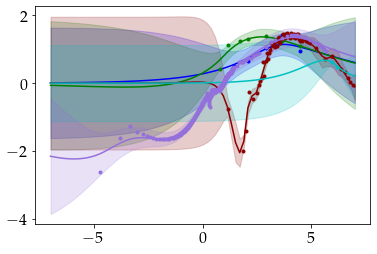

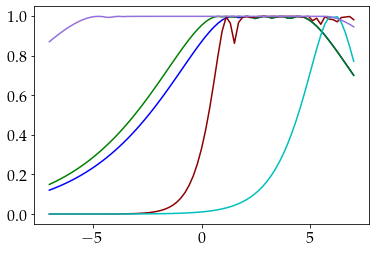

In [25]:
def max_corr(kernels,n,xm,xt):
    assert((xm.dim()==1) and (xt.dim()==1))
#     for k in range(kernels.n):
    varm = kernels.forward(n, xm-xm)
    vart = kernels.forward(n, xt-xt)
    
    xxm = varm.repeat(vart.size(0),1).t()
    xxt = vart.repeat(varm.size(0),1)
    vmvt = xxm * xxt
    
    corr = kernels.covariance(n,xm,xt) / torch.sqrt(vmvt)
    maxcor, idx = torch.max(corr,0)
    return maxcor

xtest = torch.linspace(-7,7,75)

Kb, Kp = [], []
for k in range(len(Wlog)):
    cov = cov_kern.forward(k,xd[k])
#     cov = cov_kern.forward(xd[k],xm[k])
    cov += torch.diag(ed[k]**2)
    Kb += [cov]
    Kp += [cov_kern.covariance(k,xm[k],xtest)]
# Kb = torch.block_diag(*Kd)
# Kp = cov_kern.covariance(wlogx,xtest)
# print(Kb.size(),Kp.size())

ym, y_var, zm = [], [], []
y_cov = []
for k in range(len(Wlog)):
    LKb = torch.cholesky(Kb[k])
    ym += [torch.matmul( Kp[k].t(), torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),LKb) ).squeeze()]
    y_cov += [cov_kern.covariance(k,xtest,xtest) - torch.matmul( Kp[k].t(), torch.cholesky_solve(Kp[k],LKb) ) ]
    y_var += [torch.diag(y_cov[k])]
    zm += [max_corr(cov_kern,k,xm[k],xtest)]
# print(y_var)
# print((ym + torch.sqrt(y_var)).size())
# print(cov_kern.var,cov_kern.scale)
# print(cov_kern.var1,cov_kern.var2,cov_kern.slope,cov_kern.phase)



plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k!=3)): continue
#     plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x')
    plt.plot(wlogk[:,0],wlogk[:,1],'.',color=colors[k])
    plt.plot(xtest,ym[k].detach(),'-',color=colors[k])
    plt.fill_between(
        xtest,
        # plus/minus standard deviation (70 percent confidence interval)
        (ym[k] - 2.0 * torch.sqrt(y_var[k])).detach(),
        (ym[k] + 2.0 * torch.sqrt(y_var[k])).detach(),
        alpha=0.2,
        color=colors[k],
        label="Standard deviation",
    )
#     plt.plot(xtest,(ym[k] + 2.0 * torch.sqrt(y_var[k])).detach(),'--r')
#     plt.plot(xtest,(ym[k] - 2.0 * torch.sqrt(y_var[k])).detach(),'--r')
    
plt.figure(2)
for k, wlogk in enumerate(Wlog):
#     if((k!=0) and (k!=1)): continue
    plt.plot(xtest,zm[k].detach(),'-',color=colors[k])

### Attempt 1: number of test points according to the size of trusted region

0
1
2
3
4


/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_81699/2123543455.py:29: RuntimeWarning: covariance is not positive-semidefinite.
  sample = np.random.multivariate_normal(ymm.detach().numpy(),ycov.detach().numpy())


<Figure size 432x288 with 0 Axes>

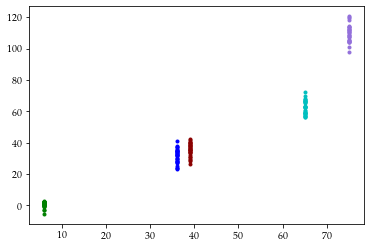

In [331]:
# compute log-normal probability
theta_ref = np.array([2.54e0,1.0,1.0,1.0])
ndim = len(theta_ref)

Nt = 30
lk = np.zeros([len(Wlog), Nt])
nk = np.zeros((len(Wlog),))
plt.figure(1)
for k in range(len(Wlog)):
    print(k)
#     if(k!=4): continue
    mask = (zm[k] > 0.8)
    xtarget = xtest[mask]
#     xtarget = torch.clone(xtest)
    nk[k] = xtarget.size(0)
    
    Kp = cov_kern.covariance(k,xm[k],xtarget)
    LKb = torch.cholesky(Kb[k])
    ycov = cov_kern.covariance(k,xtarget,xtarget) - torch.matmul( Kp.t(), torch.cholesky_solve(Kp,LKb) )
    ymm = torch.matmul( Kp.t(), torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),LKb) ).squeeze()
#     plt.plot(xtarget.detach(), ymm.detach(),'-',color=colors[k])
#     plt.plot(xtarget.detach(), (ymm + 2.0 * torch.sqrt(torch.diag(ycov))).detach(),'--',color=colors[k])
#     plt.plot(xtarget.detach(), (ymm - 2.0 * torch.sqrt(torch.diag(ycov))).detach(),'--',color=colors[k])
    
#     print(ycov)
    Lcovk = torch.cholesky(ycov)
#     print(Lcovk)
    for nn in range(Nt):
        sample = np.random.multivariate_normal(ymm.detach().numpy(),ycov.detach().numpy())
#         theta = theta_ref * (1.0 + 0.1 * np.random.randn(ndim) )
#         logModel = np.log( Excite_resonance(4,theta,(torch.exp(xtarget)+E_ext[3]).detach()) )
#         sample = logModel - Wlogm

#         plt.plot(xtarget.detach(), sample,'--',color=colors[k])
        sample = torch.tensor(sample,dtype=torch.float)
        dev = sample - ymm
        
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),Lcovk).reshape(-1)
#         print(- 0.5 * torch.dot(dev,cov_inv_y),  - torch.sum(torch.log(torch.diagonal(Lcovk))), - 0.5 * xtarget.size(0) * np.log(2.0*np.pi))
        lk[k,nn] = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(Lcovk))) - 0.5 * xtarget.size(0) * np.log(2.0*np.pi)
#         lk[k,nn] = - 0.5 * torch.dot(dev,cov_inv_y)
        
plt.figure(2)
for k in range(len(Wlog)):
    plt.plot(nk[k]*np.ones((Nt,)), lk[k,:], '.', color=colors[k])

### Attempt 2: keep the same number of points, in their own trusted region

/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_81699/375481135.py:30: RuntimeWarning: covariance is not positive-semidefinite.
  sample = np.random.multivariate_normal(ymm.detach().numpy(),ycov.detach().numpy())


<Figure size 432x288 with 0 Axes>

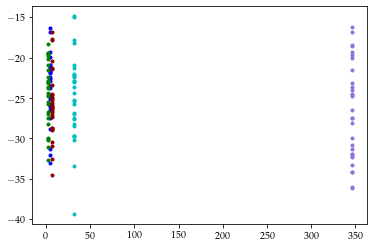

In [335]:
# compute log-normal probability
theta_ref = np.array([2.54e0,1.0,1.0,1.0])
ndim = len(theta_ref)

Ntt = 50
Nt = 30
lk = np.zeros([len(Wlog), Nt])
nk = np.zeros((len(Wlog),))
plt.figure(1)
for k in range(len(Wlog)):
#     if(k!=4): continue
    mask = (zm[k] > 0.9)
    xmin, xmax = torch.min(xtest[mask]), torch.max(xtest[mask])
    xtarget = torch.linspace(xmin,xmax,Ntt)
#     xtarget = torch.clone(xtest)
    nk[k] = xtarget.size(0)
    
    Kp = cov_kern.covariance(k,xm[k],xtarget)
    LKb = torch.cholesky(Kb[k])
    ycov = cov_kern.covariance(k,xtarget,xtarget) - torch.matmul( Kp.t(), torch.cholesky_solve(Kp,LKb) )
    ymm = torch.matmul( Kp.t(), torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),LKb) ).squeeze()
#     plt.plot(xtarget.detach(), ymm.detach(),'-',color=colors[k])
#     plt.plot(xtarget.detach(), (ymm + 2.0 * torch.sqrt(torch.diag(ycov))).detach(),'--',color=colors[k])
#     plt.plot(xtarget.detach(), (ymm - 2.0 * torch.sqrt(torch.diag(ycov))).detach(),'--',color=colors[k])
    
#     print(ycov)
    Lcovk = torch.cholesky(ycov)
#     print(Lcovk)
    for nn in range(Nt):
        sample = np.random.multivariate_normal(ymm.detach().numpy(),ycov.detach().numpy())
#         theta = theta_ref * (1.0 + 0.2 * np.random.randn(ndim) )
#         logModel = np.log( Excite_resonance(4,theta,(torch.exp(xtarget)+E_ext[3]).detach()) )
#         sample = logModel - Wlogm

#         plt.plot(xtarget.detach(), sample,'--',color=colors[k])
        sample = torch.tensor(sample,dtype=torch.float)
        dev = sample - ymm
        
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),Lcovk).reshape(-1)
#         print(- 0.5 * torch.dot(dev,cov_inv_y),  - torch.sum(torch.log(torch.diagonal(Lcovk))), - 0.5 * xtarget.size(0) * np.log(2.0*np.pi))
#         lk[k,nn] = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(Lcovk))) - 0.5 * xtarget.size(0) * np.log(2.0*np.pi)
        lk[k,nn] = - 0.5 * torch.dot(dev,cov_inv_y)
        
plt.figure(2)
for k in range(len(Wlog)):
    plt.plot(xm[k].size(0)*np.ones((Nt,)), lk[k,:], '.', color=colors[k])


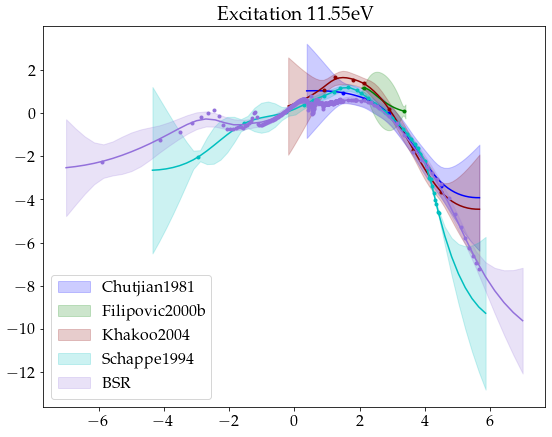

In [57]:
Ntt = 50
for k, wlogk in enumerate(Wlog):
    mask = (zm[k] > 0.9)
    xmin, xmax = torch.min(xtest[mask]), torch.max(xtest[mask])
#     if(k==4): xmin = -1.0
    xtarget = torch.linspace(xmin,xmax,Ntt)
    
    Kp = cov_kern.covariance(k,xm[k],xtarget)
    LKb = torch.cholesky(Kb[k])
    ycov = cov_kern.covariance(k,xtarget,xtarget) - torch.matmul( Kp.t(), torch.cholesky_solve(Kp,LKb) )
    ymm = torch.matmul( Kp.t(), torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),LKb) ).squeeze()
    
    plt.plot(wlogk[:,0],wlogk[:,1],'.',color=colors[k])
    plt.plot(xtarget,ymm.detach(),'-',color=colors[k])
    plt.fill_between(
        xtarget,
        # plus/minus standard deviation (70 percent confidence interval)
        (ymm - 2.0 * torch.sqrt(torch.diag(ycov))).detach(),
        (ymm + 2.0 * torch.sqrt(torch.diag(ycov))).detach(),
        alpha=0.2,
        color=colors[k],
        label=targetrefs[k],
    )
    
plt.title('Excitation 11.55eV')
plt.legend(loc="lower left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
fig.savefig("./dataset3.pdf", dpi=600)

## Bayesian inference

In [67]:
from models import *

Ntt = 50

Etarget = []
ymm, Lcovk = [], []
for k in range(len(Wlog)):
    mask = (zm[k] > 0.9)
    xmin, xmax = torch.min(xtest[mask]), torch.max(xtest[mask])
    xtarget = torch.linspace(xmin,xmax,Ntt)
    Etarget += [np.exp(xtarget.detach())+E_ext[level-1]]
    
    Kp = cov_kern.covariance(k,xm[k],xtarget)
    LKb = torch.cholesky(Kb[k])
    ycov = cov_kern.covariance(k,xtarget,xtarget) - torch.matmul( Kp.t(), torch.cholesky_solve(Kp,LKb) )
    ymm += [torch.matmul( Kp.t(), torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),LKb) ).squeeze()]

    Lcovk += [torch.cholesky(ycov)]

def log_prior_ext4(theta):
#     return 0.0
    if ((theta[0]<=0.0)):
        return - np.inf
    theta_ref = np.array([2.54e0,1.0,1.0])
#     theta_ref = np.array([51.2e0,2.0])
    sigma2 = ( 1.0 * theta_ref )**2
#     sigma2[-1] = 0.5
    lp = - 0.5 * np.sum( (theta[:3] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
#     if(theta[1]<=0.0):
#         lp -= 1e1 * theta[1]**2
#     if(theta[2]<=0.0):
#         lp -= 1e1 * theta[2]**2
        
    return lp


def log_likelihood_ext4(theta):
    # compute log-normal probability
    
#     lk = 0.0
#     for k in range(len(Wlog)):
# #         if((k!=4)): continue
#         logModel = np.log( Excite_metastable(level,theta,Etarget[k]) )            
# #         logModel = np.log( Excite_resonance(n,theta,Etarget[k]) )
#         dev = logModel - Wlogm - ymm[k]
#         dev = torch.tensor(dev,dtype=torch.float)
# #         print(dev.reshape(dev.size(0),1).dtype,Lcovk[k].dtype)
#         cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),Lcovk[k]).reshape(-1)
# #         lk += - 0.5 * torch.dot(dev,cov_inv_y).detach().numpy()
#         lk += np.exp(- 0.5 * torch.dot(dev,cov_inv_y).detach())

#     return np.log(lk)
# #     return lk

    lk = 0.0
    for k in range(len(Wlog)):
        if((k!=4)): continue
#         logModel = torch.log( Excite_metastable(level,theta,torch.exp(xm[k])+E_ext[level-1]) )            
        logModel = np.log( Excite_resonance(level,theta,torch.exp(xm[k])+E_ext[level-1]) )
        dev = logModel - Wlogm - yd[k]
#         print(dev)
        lk += - 0.5 * torch.sum( dev**2 / ed[k] / ed[k] )

#     return np.log(lk)
    return lk.detach().numpy()

def log_posterior_ext4(theta):
    lp = log_prior_ext4(theta)
    lk = log_likelihood_ext4(theta)
#     print(lp,lk)
#     if (np.isinf(lk) or np.isinf(lp)):
#         print(lp,lk)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [68]:
import emcee
nwalkers = 32
theta_ref = np.array([2.54e0,1.0,1.0])
# theta_ref = np.array([51.2e0,2.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 1.0 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ext4
)

In [69]:
sampler.run_mcmc(pos, 5000, progress=True);
# sampler.run_mcmc(None, 5000, progress=True);

tau = sampler.get_autocorr_time(tol=0)
print(tau)

/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_87383/521197677.py:59: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_resonance(level,theta,torch.exp(xm[k])+E_ext[level-1]) )
  0%|                                                             | 0/5000 [00:00<?, ?it/s]/opt/homebrew/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████████████████| 5000/5000 [00:12<00:00, 400.01it/s]

[33.18114156 55.82323546 60.42583925]


(9760, 3)


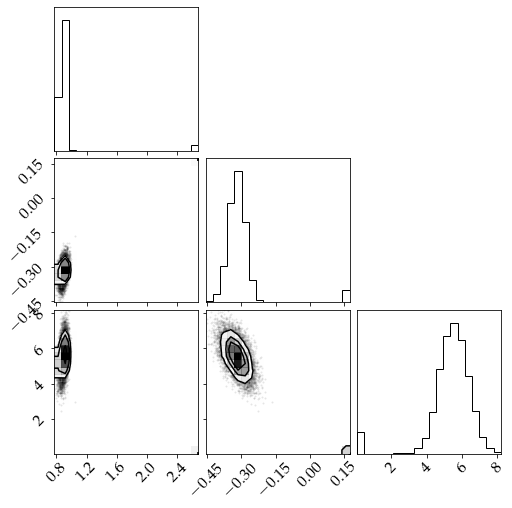

In [70]:
flat_samples = []
flat_samples += [sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)]
# flat_samples = [sampler.get_chain(flat=True)]
print(flat_samples[-1].shape)

# tmp = flat_samples,
# tmp.tofile('../crs-Bayes1/crs.excitation.level4.withBSR.modified.dat')

import corner

fig = corner.corner(flat_samples[-1]);

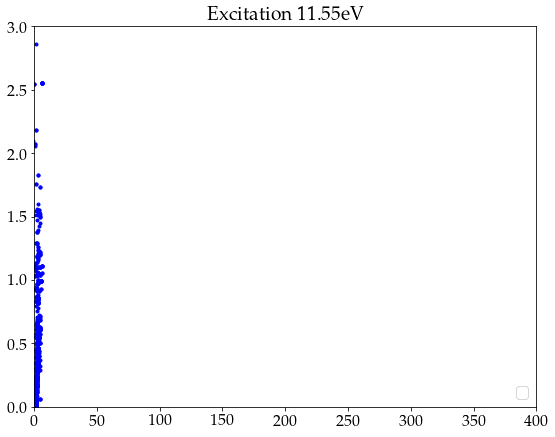

In [60]:
plt.figure(1)
for k, flat_sample in enumerate(flat_samples):
    plt.plot(flat_sample[:,0],flat_sample[:,1],'.',color=colors[k])
plt.xlim([0, 400])
plt.ylim([0, 3.0])

plt.title('Excitation 11.55eV')
plt.legend(loc="lower right")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset5.pdf", dpi=600)

(0.01, 10000.0)

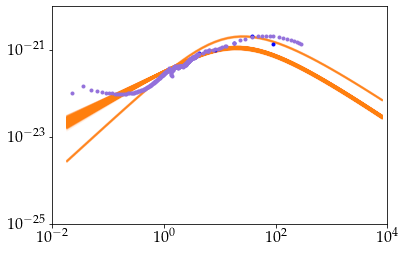

In [71]:
Nw = 50
wtest = np.linspace(-4,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]

inds = np.random.randint(len(flat_samples[0]), size=1000)
for ind in inds:
    sample = flat_samples[0][ind]
#     models = Excite_metastable(1,sample,Etest)
    models = Excite_resonance(4,sample,Etest)
    mask = models > 1.0e-24
    plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=0.1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for k, Wk in enumerate(W):
    if((k!=0) and (k!=4)): continue
#     plt.errorbar(Wk[:,0]-E_ext[3],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k])
    plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.ylim([1e-25, 1e-20])
plt.xlim([1e-2, 1e4])

tensor(-49.0228)


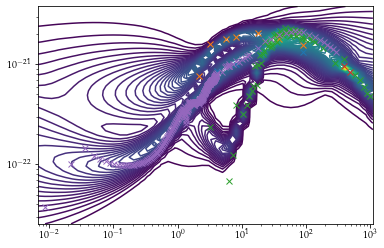

In [397]:
def max_corr(kernels,n,xm,xt):
    assert((xm.dim()==1) and (xt.dim()==1))
#     for k in range(kernels.n):
    varm = kernels.forward(n, xm-xm)
    vart = kernels.forward(n, xt-xt)
    
    xxm = varm.repeat(vart.size(0),1).t()
    xxt = vart.repeat(varm.size(0),1)
    vmvt = xxm * xxt
    
    corr = kernels.covariance(n,xm,xt) / torch.sqrt(vmvt)
    maxcor, idx = torch.max(corr,0)
    return maxcor

Ntest = 50
xtest = torch.linspace(-5,7,Ntest)
sigmatest = torch.linspace(-3,2,Ntest)
maxcor_sum = torch.zeros_like(xtest)
ym, y_var, zm = [], [], []
for k in range(len(Wlog)):
    Kb = cov_kern.forward(k,xd[k])
#     cov = cov_kern.forward(xd[k],xm[k])
    Kb += torch.diag(ed[k]**2)
    Kp = cov_kern.covariance(k,xm[k],xtest)
    
    LKb = torch.cholesky(Kb)
    ym += [torch.matmul( Kp.t(), torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),LKb) ).squeeze()]
    y_cov = cov_kern.covariance(k,xtest,xtest) - torch.matmul( Kp.t(), torch.cholesky_solve(Kp,LKb) )
    y_var += [torch.diag(y_cov)]
    
    zm += [max_corr(cov_kern,k,xm[k],xtest)]
    maxcor_sum += zm[k]
    
for zk in zm:
    zk /= maxcor_sum
    
xx, ss = np.meshgrid(xtest.detach(),sigmatest.detach())
pp = np.zeros_like(xx)
for k in range(len(Wlog)):
#     if (k!=0): continue
    yym, tmp = np.meshgrid(ym[k].detach(),sigmatest.detach())
    yyvar, tmp = np.meshgrid(y_var[k].detach(),sigmatest.detach())
    zz, tmp = np.meshgrid(zm[k].detach(),sigmatest.detach())
    
    pp += np.exp( - 0.5 * (ss - yym)**2 / yyvar ) / np.sqrt(2.0 * np.pi * yyvar) * zz
    
# fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# from matplotlib import cm
# ax.plot_surface(xx, ss, pp,
#                 cmap=cm.coolwarm, linewidth=0)
# ax.view_init(90, -90)
# ax.dist = 5
print(Wlogm)
plt.figure(1)
plt.contour(np.exp(xx),np.exp(ss+float(Wlogm.detach())),pp,100)
for k, wlogk in enumerate(Wlog):
    plt.plot(np.exp(wlogk[:,0]),np.exp(wlogk[:,1]+float(Wlogm.detach())),'x')
plt.xscale('log')
plt.yscale('log')

# temp = np.exp(xx)[:]
# temp.tofile('./xx.dat')
# temp = np.exp(ss + float(Wlogm.detach()))[:]
# temp.tofile('./ss.dat')
# temp = np.exp(pp)[:]
# temp.tofile('./pp.dat')
# temp = np.copy(Wlog[-1][:,:2])
# temp[:,0] = np.exp(temp[:,0])
# temp[:,1] = np.exp(temp[:,1]+float(Wlogm.detach()))
# temp.tofile('./BSR.excite.4.dat')

In [326]:
# cov_kern = MaternPack(len(Wlog),nu=1.5)
cov_kern = ExpKernelPack(len(Wlog))
# cov_kern = ExpTanhKernel()

optimizer = torch.optim.LBFGS(cov_kern.parameters(),lr=1e-4)

# def likelihoodEntropy(kernel):
#     lk = 0.0
    
#     for k in range(len(Wlog)):
#         cov = kernel.forward(xd[k])
# #         cov = kernel.forward(xd[k],xm[k])
#         cov += torch.diag(ed[k]**2)
# #         print(cov)
#         Lcov = torch.cholesky(cov)
#         cov_inv_y = torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),Lcov).reshape(-1)
#         lk += - 0.5 * torch.dot(yd[k],cov_inv_y) - torch.sum(torch.log(torch.diagonal(Lcov))) - 0.5 * xd[k].size(0) * np.log(2.0*np.pi)
#     return lk * torch.exp(lk)

def likelihoodEntropy(kernels):
    ent = 0.0
    
    for k in range(len(Wlog)):
        cov = kernels.forward(k, xd[k])
#         cov = kernel.forward(xd[k],xm[k])
        cov += torch.diag(ed[k]**2)
#         print(cov)
        Lcov = torch.cholesky(cov)
        cov_inv_y = torch.cholesky_solve(yd[k].reshape(yd[k].size(0),1),Lcov).reshape(-1)
        lk = - 0.5 * torch.dot(yd[k],cov_inv_y) - torch.sum(torch.log(torch.diagonal(Lcov))) - 0.5 * xd[k].size(0) * np.log(2.0*np.pi)
#         if (k==2): lk *= 0.2
        ent += lk * torch.exp(lk)
    return ent

def closure():
    lk = likelihoodEntropy(cov_kern)
    optimizer.zero_grad()
    lk.backward()
    return lk

for t in range(1000):

    # Compute and print loss.
    lk = likelihoodEntropy(cov_kern)
    if t % 100 == 99:
        print(t, lk.item())

    # Before the backward pass, use the optimizer object to zero all of the
    # gradients for the variables it will update (which are the learnable
    # weights of the model). This is because by default, gradients are
    # accumulated in buffers( i.e, not overwritten) whenever .backward()
    # is called. Checkout docs of torch.autograd.backward for more details.
    optimizer.zero_grad()

    # Backward pass: compute gradient of the loss with respect to model
    # parameters
    lk.backward()

    # Calling the step function on an Optimizer makes an update to its
    # parameters
    optimizer.step(closure)
    
for name, param in cov_kern.named_parameters():
    if param.requires_grad:
        print(name, param.data)

99 -0.7566540837287903
199 -0.756799578666687
299 -0.756821870803833
399 -0.7568576335906982
499 -0.7569053173065186
599 -0.7569378614425659
699 -0.7569611668586731
799 -0.7569963932037354
899 -0.7570253610610962
999 -0.7570655345916748
var tensor([1.0670, 1.0313, 0.8809, 1.0525, 1.0068])
scale tensor([1.0810, 1.0570, 0.9087, 0.7940, 0.8963])


torch.Size([5, 5]) torch.Size([5, 50])
tensor([0.0543, 0.0535, 0.0523, 0.0503, 0.0477, 0.0443, 0.0403, 0.0362, 0.0321,
        0.0286, 0.0259, 0.0241, 0.0231, 0.0227, 0.0228, 0.0232, 0.0235, 0.0238,
        0.0239, 0.0239, 0.0237, 0.0236, 0.0235, 0.0235, 0.0236, 0.0238, 0.0241,
        0.0244, 0.0246, 0.0250, 0.0256, 0.0267, 0.0287, 0.0315, 0.0350, 0.0390,
        0.0429, 0.0465, 0.0494, 0.0516, 0.0531, 0.0541, 0.0547, 0.0550, 0.0551,
        0.0552, 0.0552, 0.0552, 0.0552, 0.0553], grad_fn=<DiagBackward0>)
torch.Size([50])
Parameter containing:
tensor(0.0553, requires_grad=True) Parameter containing:
tensor(1.2113, requires_grad=True)


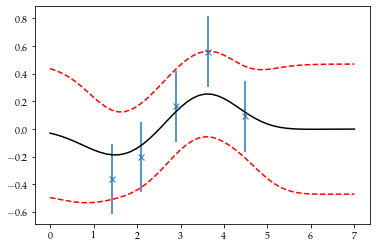

In [116]:
Kd = []
for k in range(len(Wlog)):
    cov = cov_kern.forward(xd[k])
#     cov = cov_kern.forward(xd[k],xm[k])
    cov += torch.diag(ed[k]**2)
    Kd += [cov]
Kb = torch.block_diag(*Kd)
Kp = cov_kern.covariance(wlogx,xtest)
print(Kb.size(),Kp.size())

LKb = torch.cholesky(Kb)
ym = torch.matmul( Kp.t(), torch.cholesky_solve(wlogy.reshape(wlogy.size(0),1),LKb) ).squeeze()
y_cov = cov_kern.covariance(xtest,xtest) - torch.matmul( Kp.t(), torch.cholesky_solve(Kp,LKb) )
y_var = torch.diag(y_cov)
print(y_var)
print((ym + torch.sqrt(y_var)).size())
print(cov_kern.var,cov_kern.scale)
# print(cov_kern.var1,cov_kern.var2,cov_kern.slope,cov_kern.phase)

plt.figure(1)
for wlogk in Wlog:
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x')
plt.plot(xtest,ym.detach(),'-k')
plt.plot(xtest,(ym + 2.0 * torch.sqrt(y_var)).detach(),'--r')
plt.plot(xtest,(ym - 2.0 * torch.sqrt(y_var)).detach(),'--r')

In [319]:
def max_corr(kernel,xm,xt):
    assert((xm.dim()==1) and (xt.dim()==1))
    varm = kernel.forward(xm-xm)
    vart = kernel.forward(xt-xt)
    
    xxm = varm.repeat(vart.size(0),1).t()
    xxt = vart.repeat(varm.size(0),1)
    vmvt = xxm * xxt
    
    corr = kernel.covariance(xm,xt) / torch.sqrt(vmvt)
    maxcor, idx = torch.max(corr,0)
    return maxcor

xtest = torch.linspace(0.,5.0,100)

plt.figure(1)
plt.plot(xtest, max_corr(cov_kern,xm[0],xtest).detach(),'-')
plt.plot(xm[0], max_corr(cov_kern,xm[0],xm[0]).detach(),'x')

TypeError: forward() missing 1 required positional argument: 'xd'

<Figure size 432x288 with 0 Axes>

In [430]:
# wcov_inv = np.linalg.inv(wcov)
# wcov_det = np.linalg.det(wcov)

Etest = np.exp(xtest.detach().numpy()) + E_ext[3]
Wm = float(Wlogm.detach())
Ym, Y_var, Zm = [], [], []
for k in range(len(Wlog)):
    Ym += [ym[k].detach().numpy()]
    Y_var += [y_var[k].detach().numpy()]
    Zm += [zm[k].detach().numpy()]

def log_prior_ext4(theta):
    return 0.0
#     if (theta[0]<=0.0):
#         return - np.inf
#     theta_ref = np.array([2.54e0,1.0,1.0,1.0])
#     sigma2 = ( 1.0 * theta_ref )**2
# #     sigma2[-1] = 0.5
#     return - 0.5 * np.sum( (theta - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )


def log_likelihood_ext4(theta):
    # compute log-normal probability
    n = 4
    logModel = np.log( Excite_resonance(n,theta,Etest) )
    lk = 0.0
    for k in range(len(Wlog)):
        dev = logModel - Wm - Ym[k]
        lk += np.exp( - 0.5 * dev**2 / Y_var[k] ) / np.sqrt(2.0 * np.pi * Y_var[k]) * Zm[k]

    return np.sum(np.log(lk))

def log_posterior_ext4(theta):
    lp = log_prior_ext4(theta)
    lk = log_likelihood_ext4(theta)
#     print(lp,lk)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

# def log_posterior_ext4(theta, W):
#     lp = log_prior_ext4(theta)
#     lk = 0.0
#     for Wk in W:
#         temp = log_likelihood_ext4(theta, Wk[:,0], Wk[:,1], Wk[:,2])
# #         lk += np.exp(temp)
#         lk += temp
# #     lk = np.log(lk)
#     if (not np.isfinite(lp)) or (not np.isfinite(lk)):
#         return - np.inf
#     return lp + lk


# lk = np.zeros(len(W))
# for k, Wk in enumerate(W):
#     lk[k] = log_likelihood_ext4(theta_ref, Wk[:,0], Wk[:,1], Wk[:,2])
# plt.figure(1)
# plt.plot(lk,'o')

In [437]:
import emcee
nwalkers = 32
theta_ref = np.array([2.54e0,1.0,1.0,1.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 1.0 * np.random.randn(nwalkers,ndim) )
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_ext4
)
sampler.run_mcmc(pos, 30000, progress=True);

tau = sampler.get_autocorr_time(tol=0)
print(tau)

/Users/seungwhanchung/Desktop/lxcat-review/bolsig/models.py:41: RuntimeWarning: invalid value encountered in log
  rel_factor = np.log(beta2 / (1.0 - beta2) * mc2 / 2.0 / E_ext[n-1] * C1 ) - beta2
/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_16710/3984685034.py:25: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_resonance(n,theta,Etest) )
/Users/seungwhanchung/Desktop/lxcat-review/bolsig/models.py:42: RuntimeWarning: invalid value encountered in power
  return 4. * np.pi * a0 * a0 * R0 / E * F0 / E_ext[n-1] * rel_factor * ( 1.0 - (E_ext[n-1]/E) ** alpha0 ) ** beta
  0%|                                                 | 0/30000 [00:00<?, ?it/s]/opt/homebrew/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_16710/3984685034.py:31: RuntimeWarning: divide by zero encountered in log
  r

[1985.12480394  741.69015928  918.00561527 1351.7984661 ]


In [438]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
print(flat_samples.shape)

# tmp = flat_samples,
# tmp.tofile('../crs-Bayes1/crs.excitation.level4.withBSR.modified.dat')

(2240, 4)


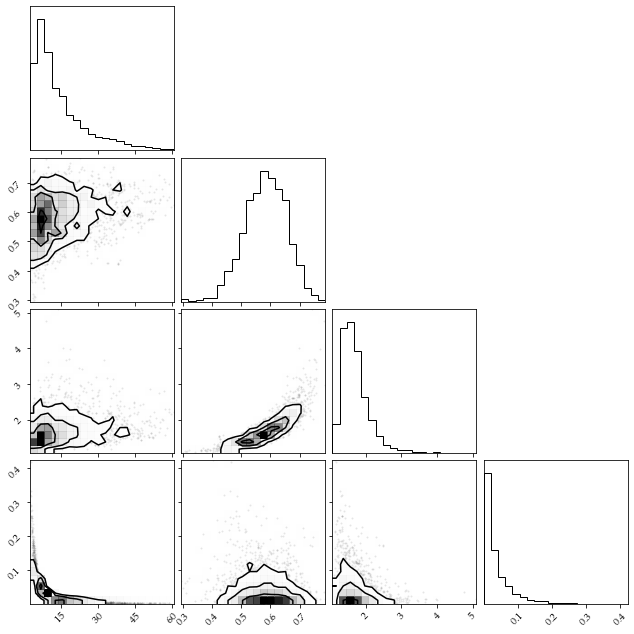

In [439]:
import corner

fig = corner.corner(flat_samples);

(0.01, 1000.0)

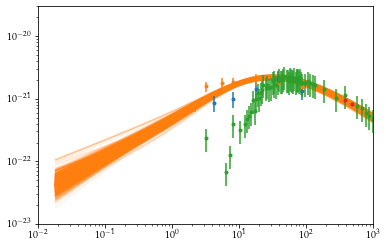

In [440]:
Nw = 50
wtest = np.linspace(-4,7.,Nw)
Etest = np.exp(wtest) + E_ext[3]

inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
    models = Excite_resonance(4,sample,Etest)
    mask = models > 1.0e-23
    plt.plot(Etest[mask]-E_ext[3], models[mask], "C1", alpha=0.1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for Wk in W[:-1]:
    plt.errorbar(Wk[:,0]-E_ext[3],Wk[:,1],yerr=Wk[:,2],fmt='.')
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.ylim([1e-23, 3e-20])
plt.xlim([1e-2, 1e3])